In [18]:
import tensorflow as tf
import numpy as np

In [20]:
data = np.loadtxt('stock_curated.csv', delimiter=',')

data = data.T
np.random.shuffle(data)
data = data.T

X = data[:252,:]
Y = data[-1:,:]

#change_mean = np.mean(X[252,:])
#change_std = np.std(X[252,:])

#X[252,:] = (X[252,:] - change_mean) / change_std

#print(np.mean(X[252,:]))
#print(np.std(X[252,:]))

#print(X.shape)
#print(Y.shape)

#print(np.mean(Y))
#print(np.std(Y))

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(253, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-8), input_shape=(253,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(253, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-8)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(253, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-8)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='linear'),
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.Huber(delta=0.5),
    metrics=['mae']
)

model.summary()


E0000 00:00:1776562773.315042   13027 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/aus/Code/school/3ML3-Final/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           254 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,076 (765.92 KB)

 Trainable params: 194,558 (759.99 KB)

 Non-trainable params: 1,518 (5.93 KB)

In [21]:
# Clip extreme outliers in Y so MSE isn't dominated by rare spikes
# (p99 ≈ 2.09, but max ≈ 19 — those few outliers monopolize the gradient)
y_lo = np.percentile(Y, 1)
y_hi = np.percentile(Y, 99)
print(f"Clipping Y to [{y_lo:.4f}, {y_hi:.4f}]  (was [{Y.min():.4f}, {Y.max():.4f}])")
Y = np.clip(Y, y_lo, y_hi)

Clipping Y to [0.1613, 1.1985]  (was [0.0493, 4.3657])


In [22]:
train_ratio = 0.8
train_size = int(X.shape[1] * train_ratio)

X_train = X[:,:train_size].T
Y_train = Y[:,:train_size].T

X_val = X[:,train_size:].T
Y_val = Y[:,train_size:].T

print(X_train.shape)
print(X_val.shape)

(59511, 252)
(14878, 252)


In [8]:
model.fit(X_train, Y_train_norm,
                  validation_data=(X_val, Y_val_norm),
                  batch_size=64, 
                  epochs=20,
                  verbose=1,
                  shuffle=True)


Epoch 1/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2915 - mae: 0.7970 - val_loss: 0.2422 - val_mae: 0.6918
Epoch 2/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2467 - mae: 0.7016 - val_loss: 0.2357 - val_mae: 0.6767
Epoch 3/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2443 - mae: 0.6960 - val_loss: 0.2371 - val_mae: 0.6801
Epoch 4/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2442 - mae: 0.6957 - val_loss: 0.2414 - val_mae: 0.6901
Epoch 5/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2437 - mae: 0.6948 - val_loss: 0.2360 - val_mae: 0.6773
Epoch 6/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2442 - mae: 0.6961 - val_loss: 0.2386 - val_mae: 0.6829
Epoch 7/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2436 - mae: 0.6943 - val_loss: 0.2409 - val_mae: 0.6889
Epoch 8/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2429 - mae: 0.6928 - val_loss: 0.2366 - val_mae: 0.6789
Epoch 9/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

KeyboardInterrupt: 

In [13]:
import matplotlib.pyplot as plt

def plot_acc_and_loss(history, title):
    plt.title("Model and Validation MAE for " + title)
    xs = list(range(1, len(history.history['mae']) + 1))
    plt.plot(xs, history.history['mae'], label="Model MAE", color="Red")
    plt.plot(xs, history.history['val_mae'], label="Validation MAE", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.show()

    plt.title("Model and Validation Loss for " + title)
    xs = list(range(1, len(history.history['val_loss']) + 1))
    plt.plot(xs, history.history['loss'], label="Model loss", color="Red")
    plt.plot(xs, history.history['val_loss'], label="Validation loss", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.legend()
    plt.show()

def prcnt_within_tolerance(x, y, model, tolerance):
    return np.count_nonzero(abs(model.predict(x) - y) <= tolerance) / x.shape[0]

In [ ]:
plot_acc_and_loss(model.history, "Model MAE")

In [ ]:
print("Prediction:", model.predict(X_val[:10]) * y_std + y_mean)
print("Label:", Y_val[:10])

In [26]:
modelMSE = tf.keras.Sequential([
    tf.keras.layers.Dense(252, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(252,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(252, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(252, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(1, activation='linear'),
])

modelMSE.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mae']
)

modelMSE.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           253 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,545 (759.94 KB)

 Trainable params: 193,033 (754.04 KB)

 Non-trainable params: 1,512 (5.91 KB)

In [27]:
modelMSE.fit(X_train, Y_train,
                  validation_data=(X_val, Y_val),
                  batch_size=64, 
                  epochs=20,
                  verbose=1,
                  shuffle=True)

Epoch 1/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1376 - mae: 0.2497 - val_loss: 0.0573 - val_mae: 0.1633
Epoch 2/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0619 - mae: 0.1728 - val_loss: 0.0591 - val_mae: 0.1603
Epoch 3/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0539 - mae: 0.1598 - val_loss: 0.0583 - val_mae: 0.1593
Epoch 4/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0514 - mae: 0.1559 - val_loss: 0.0498 - val_mae: 0.1506
Epoch 5/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0506 - mae: 0.1544 - val_loss: 0.0529 - val_mae: 0.1533
Epoch 6/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0500 - mae: 0.1536 - val_loss: 0.0555 - val_mae: 0.1540
Epoch 7/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0492 - mae: 0.1529 - val_loss: 0.0487 - val_mae: 0.1475
Epoch 8/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0484 - mae: 0.1522 - val_loss: 0.0504 - val_mae: 0.1527
Epoch 9/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

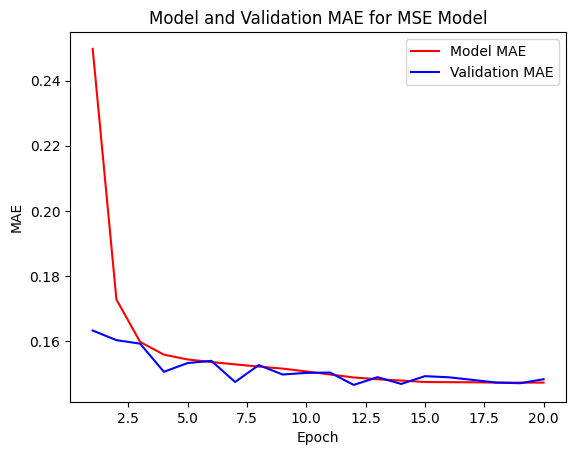

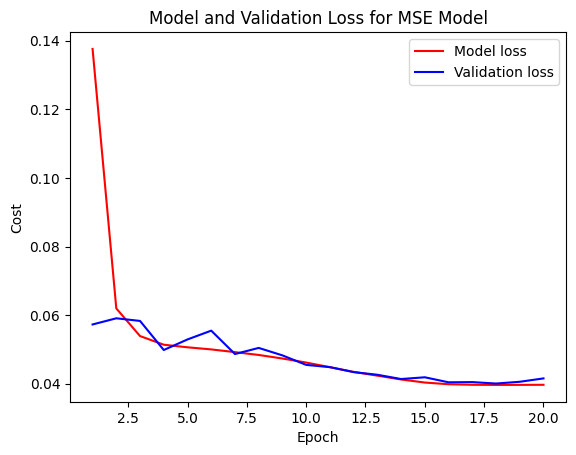

In [28]:
plot_acc_and_loss(modelMSE.history, "MSE Model")

In [30]:
print("Prediction:", modelMSE.predict(X_val[:15]))
print("Label:", Y_val[:15])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Prediction: [[0.38716605]
 [0.38537192]
 [0.42185345]
 [0.3840339 ]
 [0.40626746]
 [0.3831826 ]
 [0.31844977]
 [0.36926863]
 [0.3976841 ]
 [0.4090812 ]
 [0.3966068 ]
 [0.37012225]
 [0.4008178 ]
 [0.39423758]
 [0.41077283]]
Label: [[0.29900628]
 [0.19099243]
 [0.43510677]
 [0.33843324]
 [0.31396539]
 [0.29369308]
 [0.41852652]
 [0.47197995]
 [0.19197169]
 [0.57315929]
 [0.43047532]
 [0.69278601]
 [0.65636193]
 [0.16131475]
 [0.56375761]]


In [16]:
print("Hubard Within 5%:", prcnt_within_tolerance(X_val, Y_val_norm, model, 0.05))
print("Hubard Within 10%:", prcnt_within_tolerance(X_val, Y_val_norm, model, 0.1))
print("Hubard Within 10%:", prcnt_within_tolerance(X_val, Y_val_norm, model, 0.2))

465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step
Hubard Within 5%: 0.05701223611671373
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step
Hubard Within 10%: 0.11200752991797767
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
Hubard Within 10%: 0.21487158800591635


In [ ]:
y_std = Y.std()

print("MSE Within 0.125(Avg is 0.0987):", prcnt_within_tolerance(X_val, Y_val, modelMSE, ))
print("MSE Within 0.25 (Avg is 0.1974):", prcnt_within_tolerance(X_val, Y_val, modelMSE, 0.25))
print("MSE Within 0.5 (Avg is 0.383):", prcnt_within_tolerance(X_val, Y_val, modelMSE, 0.5))
print("MSE Within 1 (Avg is 0.68):", prcnt_within_tolerance(X_val, Y_val, modelMSE, 1))

465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step
MSE Within 0.125(Avg is 0.0987): 0.5083344535555854
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step
MSE Within 0.25 (Avg is 0.1974): 0.8898373437289958
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step
MSE Within 0.5 (Avg is 0.383): 0.9663261191020298
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step
MSE Within 1 (Avg is 0.68): 0.9998655733297486


In [ ]:
modelWD = tf.keras.Sequential([
    tf.keras.layers.Dense(1000, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(252,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(500, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='linear'),
])

modelWD.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mae']
)

modelWD.summary()

In [ ]:
modelWD.fit(X_train, Y_train_norm,
                  validation_data=(X_val, Y_val_norm),
                  batch_size=64, 
                  epochs=20,
                  verbose=1,
                  shuffle=True)

In [ ]:
print("WD Within 0.125(Avg is 0.0987):", prcnt_within_tolerance(X_val, Y_val_norm, modelWD, 0.125))
print("WD Within 0.25 (Avg is 0.1974):", prcnt_within_tolerance(X_val, Y_val_norm, modelWD, 0.25))
print("WD Within 0.5 (Avg is 0.383):", prcnt_within_tolerance(X_val, Y_val_norm, modelWD, 0.5))
print("WD Within 1 (Avg is 0.68):", prcnt_within_tolerance(X_val, Y_val_norm, modelWD, 1))

In [ ]:
plot_acc_and_loss(modelWD.history, "WD Model")

In [ ]:
modelLSTM = tf.keras.Sequential([
    tf.keras.layers.Dense(252, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(252,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Reshape((252, 1)),
    tf.keras.layers.LSTM(252),
    tf.keras.layers.Dense(1, activation='linear'),
])

modelLSTM.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mae']
)

modelLSTM.summary()

In [ ]:
modelLSTM.fit(X_train, Y_train_norm,
                  validation_data=(X_val, Y_val_norm),
                  batch_size=64, 
                  epochs=20,
                  verbose=1,
                  shuffle=True)

In [ ]:
print("LSTM Within 0.125(Avg is 0.0987):", prcnt_within_tolerance(X_val, Y_val_norm, modelLSTM, 0.125))
print("LSTM Within 0.25 (Avg is 0.1974):", prcnt_within_tolerance(X_val, Y_val_norm, modelLSTM, 0.25))
print("LSTM Within 0.5 (Avg is 0.383):", prcnt_within_tolerance(X_val, Y_val_norm, modelLSTM, 0.5))
print("LSTM Within 1 (Avg is 0.68):", prcnt_within_tolerance(X_val, Y_val_norm, modelLSTM, 1))

In [ ]:
plot_acc_and_loss(modelLSTM.history, "LSTM Model")

In [ ]:
def mean_quadratic_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    squared_error = tf.square(y_pred - y_true)
    return tf.reduce_mean(squared_error, axis=-1)


modelMQE = tf.keras.Sequential([
    tf.keras.layers.Dense(253, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(253,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(253, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(253, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(126, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.Dense(1, activation='linear'),
])

modelMQE.compile(
    optimizer='adam',
    loss=mean_quadratic_error,
    metrics=['mae']
)

modelMQE.summary()

In [ ]:
historyMQE = modelMQE.fit(
    X_train,
    Y_train_norm,
    validation_data=(X_val, Y_val_norm),
    batch_size=64,
    epochs=20,
    verbose=1,
    shuffle=True,
)

In [ ]:
plot_acc_and_loss(historyMQE, "Custom MQE Model")

print("Prediction:", modelMQE.predict(X_val[:15]) * y_std + y_mean)
print("Label:", Y_val[:15])